# Importing Data & Libs'

In [ ]:
import numpy as np
import pandas as pd
import datetime
import os

In [ ]:
df = pd.read_csv('/content/TSLA.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


# EDA

In [ ]:
print('First Trade Date: ', df['Date'].min())
print('Last Trade Date: ', df['Date'].max())

First Trade Date:  2010-06-29
Last Trade Date:  2021-10-01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2836 entries, 0 to 2835
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2836 non-null   object 
 1   Open       2836 non-null   float64
 2   High       2836 non-null   float64
 3   Low        2836 non-null   float64
 4   Close      2836 non-null   float64
 5   Adj Close  2836 non-null   float64
 6   Volume     2836 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 155.2+ KB


In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
df.drop('Adj Close', axis=1, inplace=True)

# Plotting TimeSeries

In [ ]:
import matplotlib.pyplot as plt

def timeseries(x_axis, y_axis, x_label, y_label):
    plt.figure(figsize= (10, 5))
    plt.plot(x_axis, y_axis)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


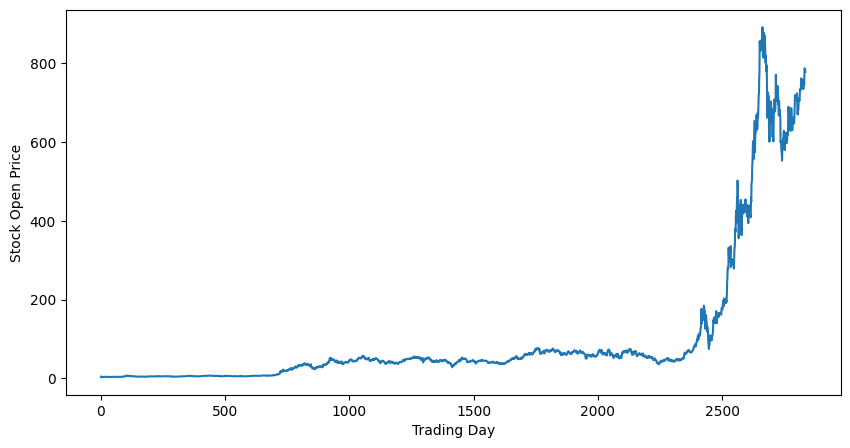

In [ ]:
timeseries(df.index, df['Open'], 'Trading Day', 'Stock Open Price')

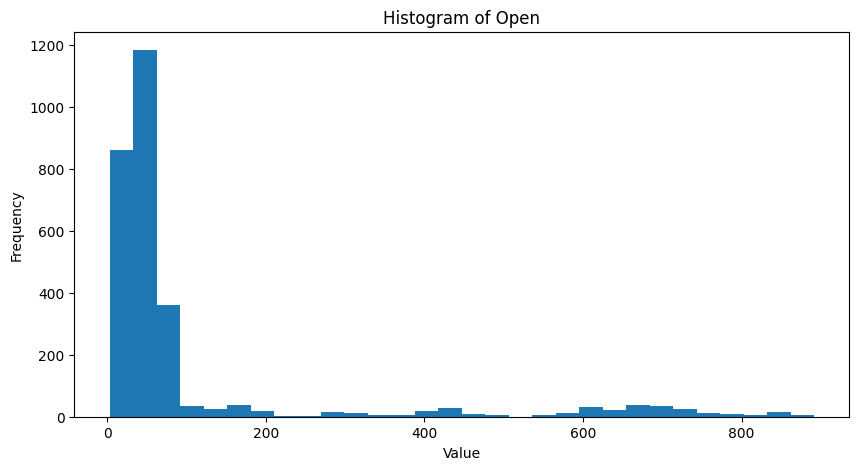

In [ ]:
def plot_histogram(x):
    plt.figure(figsize= (10, 5))
    plt.hist(x, bins=30)
    var_name = x.name
    plt.title(f'Histogram of {var_name}'.format(var_name= var_name))
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

plot_histogram(df['Open'])

# Generating & Plotting Train & Test DataSet

In [ ]:
train_size = int(len(df) * 0.8)
train_dataset, test_dataset = df.iloc[:int(train_size)], df.iloc[int(train_size):]

Dimension of Train Data:  (2268, 6)
Dimension of Test Data:  (568, 6)


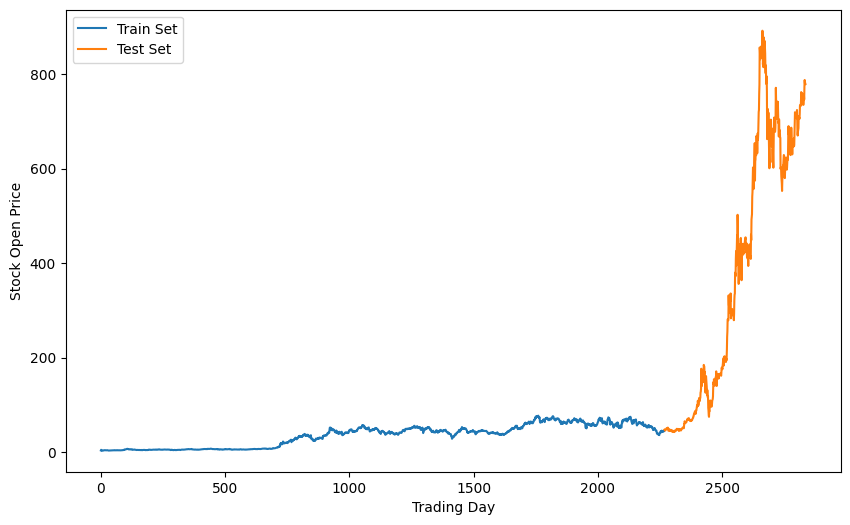

In [ ]:
plt.figure(figsize= (10, 6))
plt.plot(train_dataset.Open)
plt.plot(test_dataset.Open)
plt.xlabel('Trading Day')
plt.ylabel('Stock Open Price')
plt.legend(['Train Set', 'Test Set'], loc= 'upper left')
print('Dimension of Train Data: ', train_dataset.shape)
print('Dimension of Test Data: ', test_dataset.shape)

# Splitting Data

In [ ]:
# Split train data to X and y
X_train = train_dataset.drop(['Open', 'Date'], axis=1)
y_train = train_dataset.loc[:,['Open']]

# Split test data to X and y
X_test = test_dataset.drop(['Open', 'Date'], axis=1)
y_test = test_dataset.loc[:,['Open']]

In [ ]:
X_test.shape, y_test.shape

((568, 4), (568, 1))

# Encoding Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape, X_test_scaled.shape

((2268, 4), (568, 4))

# DataSet Creation

In [ ]:
def create_dataset(x, y, time_steps= 1):
    xs, ys = [], []
# Look Back Window Func.
    for i in range(len(x) - time_steps): # We subt time_steps coz we have to left the very last datapoints.
        x_slice = x[i: (i + time_steps)]
        xs.append(x_slice)
        ys.append(y.iloc[i + time_steps])
    return np.array(xs), np.array(ys)

# For test data.
x_test, y_test = create_dataset(X_test_scaled, y_test, 20) # 20 is time_steps.
# For train data.
x_train, y_train = create_dataset(X_train_scaled, y_train, 20)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2248, 20, 4) (548, 20, 4) (2248, 1) (548, 1)


# Bi-LSTM & LSTM & GRU Models

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, GRU, Dense, Input, Layer, Dropout
from tensorflow.keras import layers
from tensorflow.keras import callbacks


def create_BILSTM_model(unit):
    model = Sequential()
    model.add(Bidirectional(LSTM(units= unit, return_sequences= True), input_shape= (x_train.shape[1], x_train.shape[2])))
    model.add(Bidirectional(LSTM(units= unit)))
    model.add(Dense(1))
    model.compile(loss= 'mean_squared_error', optimizer= 'adam')
    return model

In [ ]:
def create_LSTM_model(unit):
    model = Sequential()
    model.add(LSTM(units= unit, return_sequences= True, input_shape= (x_train.shape[1], x_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(units= unit))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(loss= 'mean_squared_error', optimizer= 'adam')
    return model

In [ ]:
def create_GRU_model(unit):
    model = Sequential()
    model.add(GRU(units= unit, return_sequences= True, input_shape= (x_train.shape[1], x_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(GRU(units= unit))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(loss= 'mean_squared_error', optimizer= 'adam')
    return model

In [ ]:
def fit_models(model):
    early_stopping = callbacks.EarlyStopping(monitor= 'val_loss', patience= 5)
    history = model.fit(x_train, y_train, epochs= 15, batch_size= 32, validation_split= 0.2, callbacks= [early_stopping])
    return history

history_bilstm = fit_models(create_BILSTM_model(256))
history_lstm = fit_models(create_LSTM_model(256))
history_gru = fit_models(create_GRU_model(256))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 784.9133 - val_loss: 1112.1158
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 293.5037 - val_loss: 553.0190
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 79.4510 - val_loss: 317.0366
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 52.4962 - val_loss: 463.8130
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 130.0257 - val_loss: 101.6259
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 18.9459 - val_loss: 96.9977
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 16.6389 - val_loss: 53.5529
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 10.2222 - val_loss: 27.4316
Epoch 9/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0543 - val_loss: 19.7571
Epoch 10/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9458 - val_loss: 17.3243
Epoch 11/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.8710 - val_loss: 13.4376
Epoch 12/15
57/57 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 953.4931 - val_loss: 1857.7983
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 530.2058 - val_loss: 1458.2301
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 444.2567 - val_loss: 1231.9116
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 434.7223 - val_loss: 1139.0065
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 424.5239 - val_loss: 1091.4885
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 431.3322 - val_loss: 1060.6761
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 434.2288 - val_loss: 1068.4983
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 421.8730 - val_loss: 1065.1006
Epoch 9/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 430.0125 - val_loss: 1069.0970
Epoch 10/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 429.3066 - val_loss: 1074.3833
Epoch 11/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 431.7278 - val_loss: 1061.9011
Epoch 1/15
57/57 ━━━━━━━━━━━

# Plotting Traning & Validation Loss

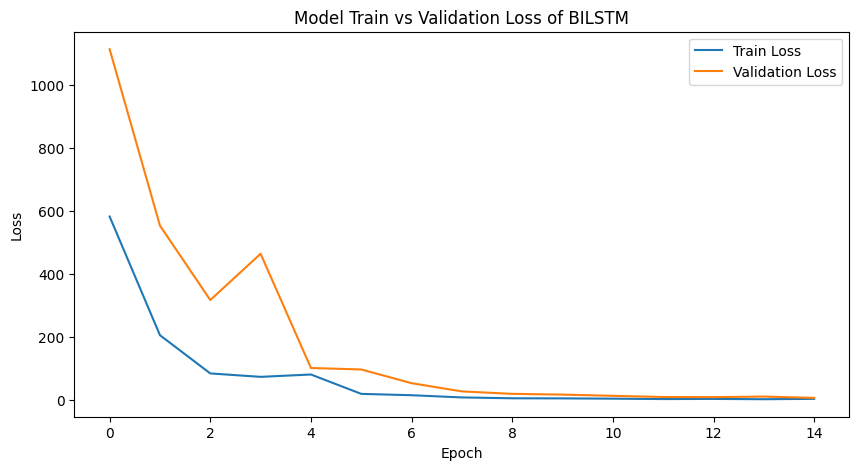

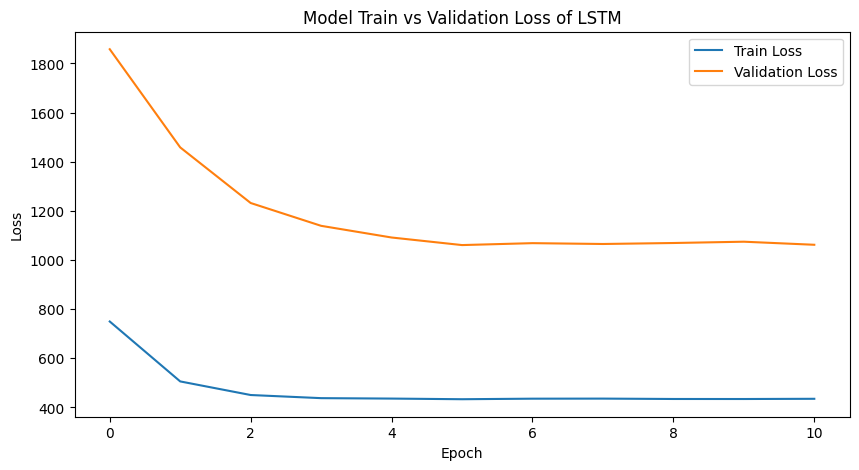

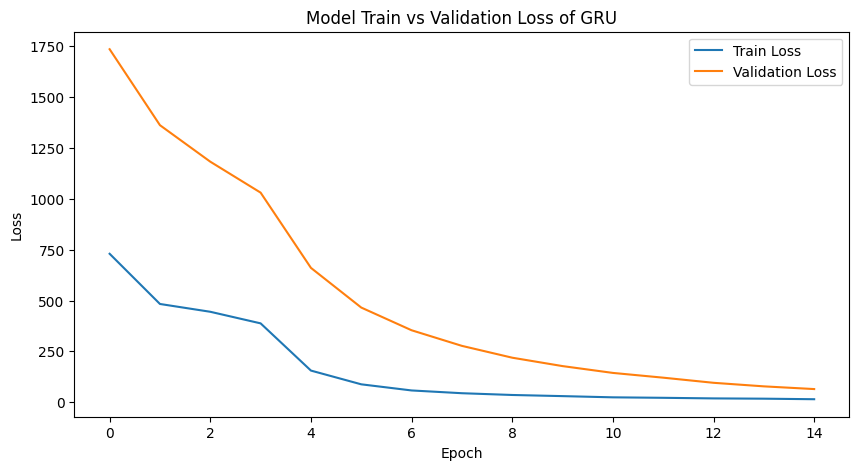

In [ ]:
def plot_loss(history, model_name):
    plt.figure(figsize= (10, 5))
    plt.plot(history.history['loss'], label= 'Training Loss')
    plt.plot(history.history['val_loss'], label= 'Validation Loss')
    plt.title(f'Model Training vs Validation Loss of {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss(history_bilstm, 'BILSTM')
plot_loss(history_lstm, 'LSTM')
plot_loss(history_gru, 'GRU')

# Predicting Models

In [ ]:
def prediction(model):
    pred = model.predict(x_test)
    dummy_array = np.zeros((pred.shape[0], X_train_scaled.shape[1])) # pred made by model , no of features.
    dummy_array[:, 0] = pred[:, 0] # places single col of pred in-front of dummy array(de-normalizing).
    pred = scaler.inverse_transform(dummy_array)[:, 0]
    return pred

pred_bilstm = prediction(create_BILSTM_model(128))
pred_lstm = prediction(create_LSTM_model(128))
pred_gru = prediction(create_GRU_model(128))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
 1/18 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


# Plotting Future & Prediction

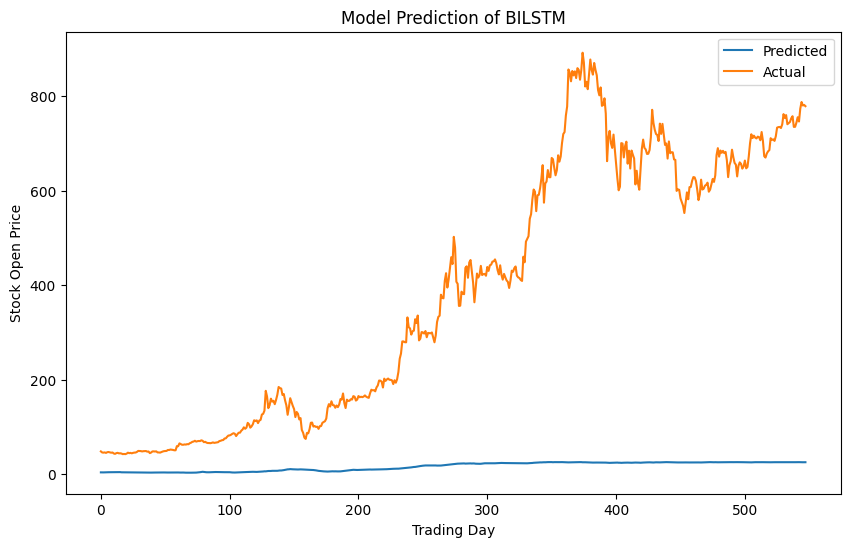

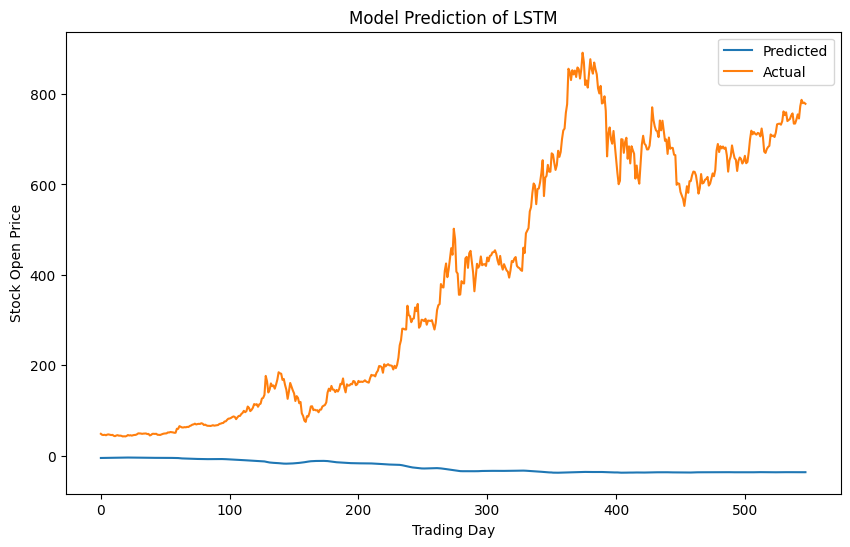

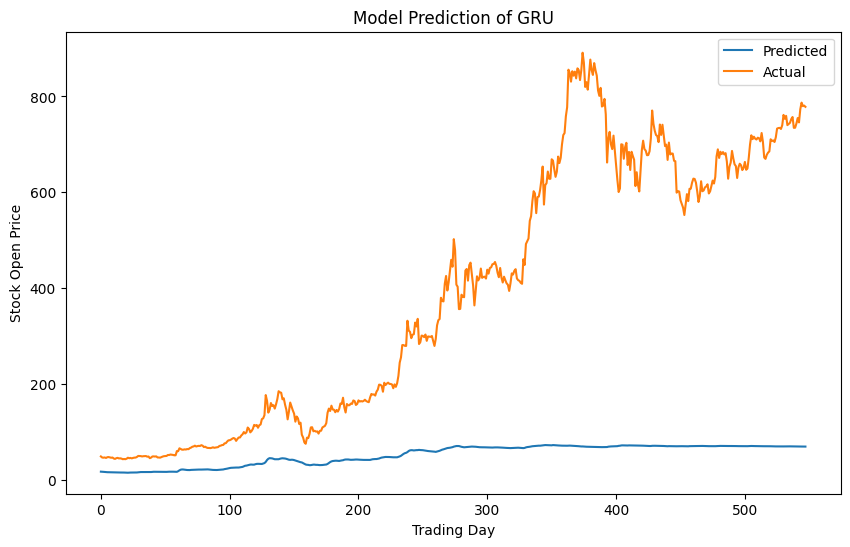

In [ ]:
def plot_figure(prediction, model_name, y_test):
    plt.figure(figsize= (10, 6))
    future_rnge = len(prediction)
    plt.plot(np.arange(future_rnge), prediction, label= 'Predicted')
    plt.plot(np.arange(future_rnge), y_test, label= 'Actual')
    plt.title(f'Model Prediction of {model_name}')
    plt.xlabel('Trading Day')
    plt.ylabel('Stock Open Price')
    plt.legend()
    plt.show()

plot_figure(pred_bilstm, 'BILSTM', y_test)
plot_figure(pred_lstm, 'LSTM', y_test)
plot_figure(pred_gru, 'GRU', y_test)

# Models Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_perf(prediction, actual, model_name):
    errors = prediction - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, prediction)

    print(f'{model_name} Performance:')
    print(f'  MSE: {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE: {mae:.4f}')



In [ ]:
evaluate_perf(pred_bilstm, y_test, 'BILSTM')
evaluate_perf(pred_lstm, y_test, 'LSTM')
evaluate_perf(pred_gru, y_test, 'GRU')

BILSTM Performance:
  MSE: 212601.4190
  RMSE: 461.0872
  MAE: 370.8121
LSTM Performance:
  MSE: 244750.3452
  RMSE: 494.7225
  MAE: 411.7932
GRU Performance:
  MSE: 188044.9351
  RMSE: 433.6415
  MAE: 335.5483
